In [6]:
import pandas as pd

# https://www.kaggle.com/code/rajeshjnv/mall-customer-visually-analysis-k-means/data
df = pd.read_csv('shopping-data.csv')


X = df.drop(columns=["CustomerID"])

X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [7]:
from sklearn.preprocessing import MinMaxScaler

data_scaler = MinMaxScaler(feature_range=(1,99))

data_scaler.fit(X)

TX=data_scaler.transform(X)
print(TX)

X['Income']=TX[:,0]

X['Score']=TX[:,1]

[[ 1.         39.        ]
 [ 1.         81.        ]
 [ 1.80327869  6.        ]
 [ 1.80327869 77.        ]
 [ 2.60655738 40.        ]
 [ 2.60655738 76.        ]
 [ 3.40983607  6.        ]
 [ 3.40983607 94.        ]
 [ 4.21311475  3.        ]
 [ 4.21311475 72.        ]
 [ 4.21311475 14.        ]
 [ 4.21311475 99.        ]
 [ 5.01639344 15.        ]
 [ 5.01639344 77.        ]
 [ 5.01639344 13.        ]
 [ 5.01639344 79.        ]
 [ 5.81967213 35.        ]
 [ 5.81967213 66.        ]
 [ 7.42622951 29.        ]
 [ 7.42622951 98.        ]
 [ 8.2295082  35.        ]
 [ 8.2295082  73.        ]
 [ 9.03278689  5.        ]
 [ 9.03278689 73.        ]
 [11.44262295 14.        ]
 [11.44262295 82.        ]
 [11.44262295 32.        ]
 [11.44262295 61.        ]
 [12.24590164 31.        ]
 [12.24590164 87.        ]
 [13.04918033  4.        ]
 [13.04918033 73.        ]
 [15.45901639  4.        ]
 [15.45901639 92.        ]
 [15.45901639 14.        ]
 [15.45901639 81.        ]
 [16.26229508 17.        ]
 

In [8]:

from sklearn.cluster import KMeans

X = X[['Income','Score']]

from sklearn.metrics import silhouette_score

range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
max_silhouette_score=0
best_n_clusters=0
for n_clusters in range_n_clusters:

    model = KMeans(n_clusters=n_clusters)
    model.fit(X)
    
    silhouette_avg = silhouette_score(X, model.labels_)
    if silhouette_avg>max_silhouette_score:
        max_silhouette_score=silhouette_avg
        best_n_clusters=n_clusters
    print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    round(silhouette_avg,2),
    )
print("Best n_cluster= ",best_n_clusters, " with silhouette score= ", round(max_silhouette_score,2))

For n_clusters = 2 The average silhouette_score is : 0.33
For n_clusters = 3 The average silhouette_score is : 0.45
For n_clusters = 4 The average silhouette_score is : 0.5
For n_clusters = 5 The average silhouette_score is : 0.56
For n_clusters = 6 The average silhouette_score is : 0.54
For n_clusters = 7 The average silhouette_score is : 0.44
For n_clusters = 8 The average silhouette_score is : 0.41
Best n_cluster=  5  with silhouette score=  0.56


In [9]:
n_clusters=best_n_clusters
kmeans = KMeans(n_clusters=n_clusters,random_state=0)

kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",0
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)","[[

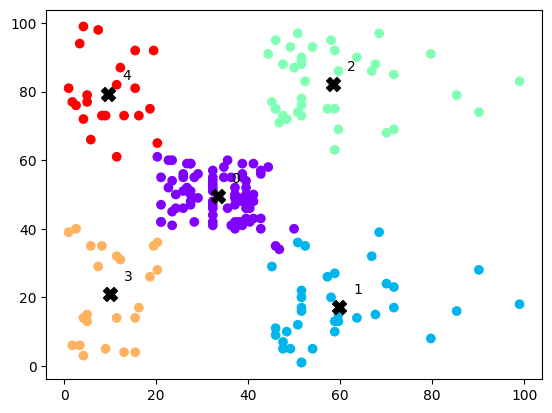

In [10]:
import matplotlib.pyplot as plt

X1 = X["Income"]
X2 = X["Score"]

plt.scatter(X1, X2, c=kmeans.labels_, cmap='rainbow')

XCenters = kmeans.cluster_centers_[:, 0]
YCenters = kmeans.cluster_centers_[:, 1]

plt.scatter(XCenters, YCenters, color='black', marker='X', s=100)  # Added marker sizing for visual clarity

for i in range(best_n_clusters):
    plt.annotate(
        str(i),
        xy=(XCenters[i], YCenters[i]), 
        textcoords='offset points',
        xytext=(10, 10)
    )

plt.show()

In [11]:
cluster_map = pd.DataFrame()
cluster_map['CustomerID'] = df['CustomerID']

cluster_map['cluster'] = kmeans.labels_

cluster_map[cluster_map.cluster == 2]

,CustomerID,cluster
123,124,2
125,126,2
127,128,2
129,130,2
131,132,2
133,134,2
135,136,2
137,138,2
139,140,2
141,142,2
